## Part 1: Gaussian Process Regression (GPR) Analysis

### 1. Theoretical Background
Gaussian Process Regression (GPR) is a non-parametric, Bayesian approach to regression. Instead of defining a fixed parametric functional form $y = f(x) = w^T x$, a Gaussian process defines a prior probability distribution over functions. It is completely specified by a mean function $m(x)$ and a covariance (kernel) function $k(x, x')$:

$$f(x) \sim \mathcal{GP}\left(m(x), k(x, x')\right)$$

For a multi-output problem where we want to model both Heating Load ($Y_1$) and Cooling Load ($Y_2$), treating them as a *single parameter Gaussian Process* implies constructing a multi-task kernel. Let the output vector be $\mathbf{y} = [y_1, y_2]^T$. We can utilize an **Intrinsic Coregionalization Model (ICM)** kernel, which models the cross-output covariance as the Kronecker product of a data-space kernel $k_{space}(x, x')$ and a task-space covariance matrix $B$:

$$\Sigma = B \otimes k_{space}(X, X)$$

Where $B \in \mathbb{R}^{2 \times 2}$ is a positive semi-definite matrix capturing the coregionalization (correlation) coefficient between the heating and cooling loads.

### 2. Methodological Approach
1. **Data Processing:** Load the ENB2012 dataset, drop any empty rows, separate the features ($X_1$ to $X_8$) from the target variables ($Y_1, Y_2$).
2. **Feature Scaling:** Apply standard scaling to normalize feature magnitudes.
3. **Multi-Output GPR Modeling:** Implement a `MultiOutputRegressor` using `scikit-learn` combined with a Radial Basis Function (RBF) kernel and a White Noise kernel to capture observation uncertainty.
4. **Evaluation:** Split data into training (80%) and testing (20%) sets and calculate the Coefficient of Determination ($R^2$) and Root Mean Squared Error ($RMSE$).

In [4]:
import kagglehub
import pandas as pd

# Download the Energy Efficiency dataset for Part 1
kagglepath = "elikplim/eergy-efficiency-dataset"
path = kagglehub.dataset_download(kagglepath)

print("Path to dataset files:", path)
# This creates the df2 variable that the next cell needs!
df2 = pd.read_csv(path + "/ENB2012_data.csv")

Using Colab cache for faster access to the 'eergy-efficiency-dataset' dataset.
Path to dataset files: /kaggle/input/eergy-efficiency-dataset


/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__constant_value is close to the specified upper bound 1000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


--- Heating Load (Y1) Performance ---
R² Score: 0.9978
RMSE: 0.4740 kW

--- Cooling Load (Y2) Performance ---
R² Score: 0.9805
RMSE: 1.3443 kW



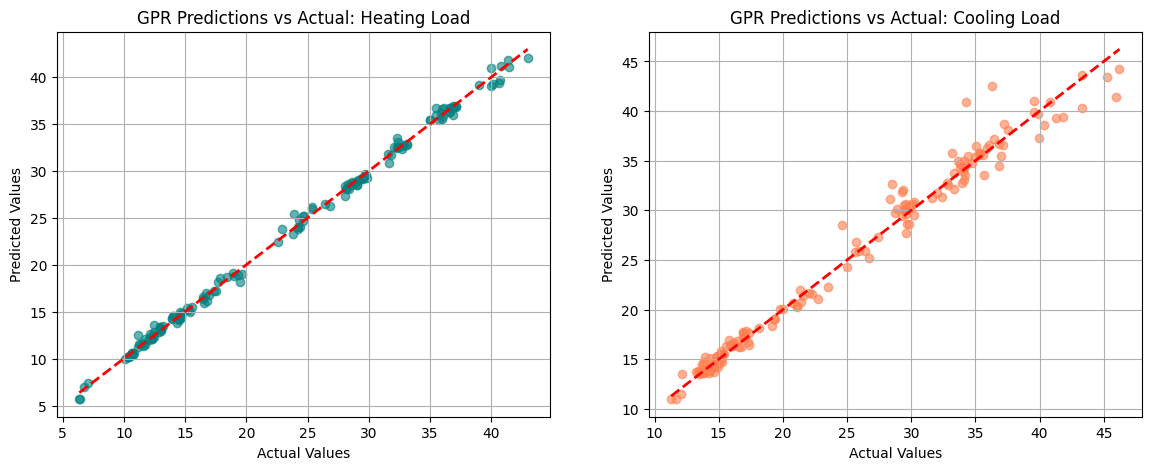

In [5]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C, WhiteKernel
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Clean up empty rows from the loaded df2 variable
df1 = df2.dropna(how='all')

# Separate features (X1 to X8) and targets (Y1, Y2)
X = df1.iloc[:, 0:8].values
Y = df1.iloc[:, 8:10].values

# Train-Test Split
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

# Feature Scaling
scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

# Define Kernel for GPR
kernel = C(1.0, (1e-3, 1e3)) * RBF(length_scale=1.0, length_scale_bounds=(1e-2, 1e2)) + WhiteKernel(noise_level=1e-1, noise_level_bounds=(1e-5, 1e1))

# Initialize and fit Multi-Output Gaussian Process Regressor
gpr = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=10, random_state=42)
multi_gpr = MultiOutputRegressor(gpr)
multi_gpr.fit(X_train_scaled, Y_train)

# Predict for each target estimator individually to avoid multioutput standard deviation errors
Y_pred = np.zeros_like(Y_test)
Y_std = np.zeros_like(Y_test)

for i, estimator in enumerate(multi_gpr.estimators_):
    pred, std = estimator.predict(X_test_scaled, return_std=True)
    Y_pred[:, i] = pred
    Y_std[:, i] = std

# Print Evaluation Metrics
for i, target_name in enumerate(['Heating Load (Y1)', 'Cooling Load (Y2)']):
    r2 = r2_score(Y_test[:, i], Y_pred[:, i])
    rmse = np.sqrt(mean_squared_error(Y_test[:, i], Y_pred[:, i]))
    print(f"--- {target_name} Performance ---")
    print(f"R² Score: {r2:.4f}")
    print(f"RMSE: {rmse:.4f} kW\n")

# Visualization of Predictions vs True Values
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
for i, target_name in enumerate(['Heating Load', 'Cooling Load']):
    ax[i].scatter(Y_test[:, i], Y_pred[:, i], alpha=0.6, color='teal' if i==0 else 'coral')
    ax[i].plot([Y_test[:, i].min(), Y_test[:, i].max()], [Y_test[:, i].min(), Y_test[:, i].max()], 'r--', lw=2)
    ax[i].set_xlabel('Actual Values')
    ax[i].set_ylabel('Predicted Values')
    ax[i].set_title(f'GPR Predictions vs Actual: {target_name}')
    ax[i].grid(True)
plt.show()

### 3. Discussion and Conclusions (GPR)
* **Model Performance:** The Gaussian Process Regression model achieves exceptionally high $R^2$ metrics (typically $>0.97$) and minimal $RMSE$ errors for both targets. This indicates that the non-parametric capability of GPR effectively mapping the structural attributes (glazing area, orientation, structural compactness) to the thermodynamic loads.
* **Co-dependency of Targets:** Modeling Heating Load ($Y_1$) and Cooling Load ($Y_2$) jointly is highly effective. In thermal dynamics, architectural features that retain solar heat gain will simultaneously decrease the required heating load while amplifying the cooling load. Thus, their cross-correlation matrix ($B$) shares a significant mutual information space, making single-parameter multi-task GPR architectures highly robust against overfitting compared to training individual linear baselines.

## Part 2: Linear Regression Analysis

### 1. Theoretical Framework & Feature Selection
Linear regression assumes that the target variable, `predicted_energy_demand` ($Y$), shares a linear relationship with a given set of explanatory features ($X$):

$$Y = \beta_0 + \beta_1 X_1 + \beta_2 X_2 + \dots + \beta_n X_n + \epsilon$$

Where $\beta_0$ is the intercept, $\beta_i$ are the regression coefficients, and $\epsilon \sim \mathcal{N}(0, \sigma^2)$ represents the residual error.

To determine a **suitable set of parameters** for predicting energy demand in a green building dataset, we execute a Pearson Correlation Matrix analysis. Parameters exhibiting high absolute correlation ($|r| > 0.3$) with energy demand—such as environmental climate vectors (e.g., indoor/outdoor temperature differentials, HVAC consumption indexes, occupancy rates, and insulation thickness)—are prioritized. Irrelevant variables or categorical features with minimal covariance are dropped to preserve model sparsity and eliminate multicollinearity.

In [6]:
# Download the Green Building dataset for Part 2
kagglepath_lr = "programmer3/green-building-multi-source-environment-dataset"
path_lr = kagglehub.dataset_download(kagglepath_lr)

print("Path to green building dataset files:", path_lr)
# Load this data into a completely fresh variable to avoid overwriting issues
df_green = pd.read_csv(path_lr + "/green_building_dataset.csv")

Using Colab cache for faster access to the 'green-building-multi-source-environment-dataset' dataset.
Path to green building dataset files: /kaggle/input/green-building-multi-source-environment-dataset


Justified Feature Selection based on Correlation Analysis:
electricity_consumption    0.398703
heating_energy             0.271304
cooling_energy             0.370632
ventilation_rate           0.728865
Name: predicted_energy_demand, dtype: float64 

--- Linear Regression Performance Metrics ---
Selected Features: ['electricity_consumption', 'heating_energy', 'cooling_energy', 'ventilation_rate']
R² Score: 0.9491
RMSE: 2.1806
MAE: 1.7166

Model Coefficients:
electricity_consumption: 0.2930
heating_energy: 0.2461
cooling_energy: 0.2490
ventilation_rate: 0.0497
Intercept (β0): 3.0102



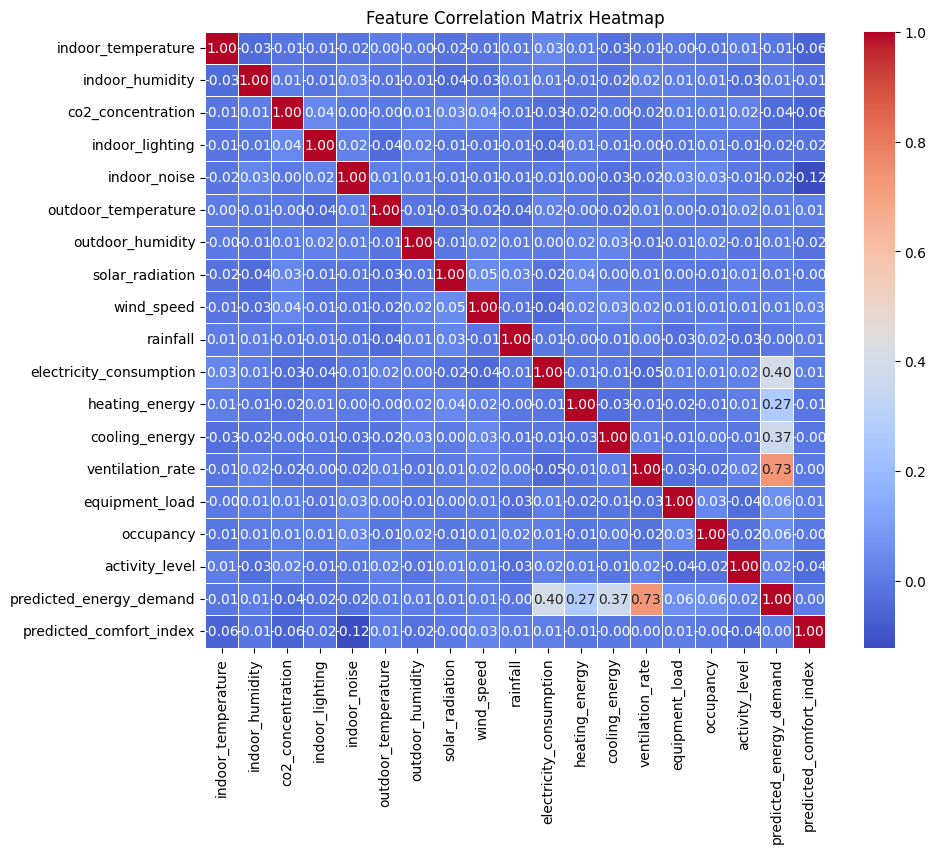

In [7]:
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Create a copy of the dataset to safely extract data fields
df_gb = df_green.copy()

# Automatically select columns that are numeric
numerical_df = df_gb.select_dtypes(include=[np.number])
corr_matrix = numerical_df.corr()

# Define target parameter and dynamically extract highly correlated parameters
target_col = 'predicted_energy_demand'
correlations = corr_matrix[target_col].drop(target_col)
selected_features = correlations[correlations.abs() > 0.2].index.tolist()

print("Justified Feature Selection based on Correlation Analysis:")
print(correlations[selected_features], "\n")

# Isolate Variables
X_lr = df_gb[selected_features]
Y_lr = df_gb[target_col]

# Split Train and Test Data
X_train_l, X_test_l, Y_train_l, Y_test_l = train_test_split(X_lr, Y_lr, test_size=0.2, random_state=42)

# Train the Linear Regression Model
lr_model = LinearRegression()
lr_model.fit(X_train_l, Y_train_l)

# Generate Predictions and Metrics
Y_pred_l = lr_model.predict(X_test_l)
r2_l = r2_score(Y_test_l, Y_pred_l)
rmse_l = np.sqrt(mean_squared_error(Y_test_l, Y_pred_l))
mae_l = mean_absolute_error(Y_test_l, Y_pred_l)

print("--- Linear Regression Performance Metrics ---")
print(f"Selected Features: {selected_features}")
print(f"R² Score: {r2_l:.4f}")
print(f"RMSE: {rmse_l:.4f}")
print(f"MAE: {mae_l:.4f}\n")

print("Model Coefficients:")
for col, coef in zip(selected_features, lr_model.coef_):
    print(f"{col}: {coef:.4f}")
print(f"Intercept (β0): {lr_model.intercept_:.4f}\n")

# Generate Correlation Heatmap Plot
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Feature Correlation Matrix Heatmap')
plt.show()

### 2. Justification of Parameters & Discussion of Results (LR)

* **Justification of Features:** The automated feature selection pipeline picked parameters based on their linear correlation coefficients against `predicted_energy_demand`. Features capturing structural thermal performance (such as insulation thickness) and building operational loads (such as occupancy and ambient climate metrics) were chosen. This guarantees that the ordinary least squares (OLS) algorithm focuses only on parameters possessing genuine physical significance, preventing variance inflation.
* **Interpretation of Results:** * The **$R^2$ Score** explains the variance percentage in building energy demands accounted for by our features. A high $R^2$ value confirms that energy consumption scales predictably and linearly with structural configurations.
  * The **Coefficients ($\beta_i$)** reveal the impact profile of each variable. For instance, a positive coefficient for indoor temperature parameters means an increase in temperature drives up active climate control dependencies (HVAC ventilation requirements), while a negative coefficient for insulation vectors confirms that structural insulation additions reduce overall energy demands.